# Porównanie Profili Naukowców: Center of Gravity

Ten notebook porównuje jak różne modele embeddingowe tworzą profile naukowców.

## Metodologia
1. Dla każdego naukowca embedujemy jego prace osobno (title lub abstract)
2. Obliczamy **center of gravity** (centroid) - średnią embeddingów wszystkich prac
3. Ten centroid reprezentuje profil naukowca
4. Dla każdego naukowca znajdujemy k najbliższych sąsiadów
5. Porównujemy top-k sąsiadów między różnymi modelami

## 1. Setup i Import bibliotek

In [18]:
# Instalacja potrzebnych bibliotek
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn plotly -q

In [19]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Biblioteki załadowane")

✅ Biblioteki załadowane


## 2. Konfiguracja ścieżek i parametrów

**Dostosuj ścieżki do swoich plików:**

In [20]:
# Ścieżki do plików (dostosuj do swoich danych)
SCIENTISTS_FILE = '../data/scientists_with_identifiers.csv'
WORKS_FILE = '../data/titles_with_abstracts.csv'
EMBEDDINGS_DIR = '../embeddings'  # Katalog do zapisywania embeddingów (starych profili)
WORK_EMBEDDINGS_DIR = '../embeddings'  # Katalog z embeddingami poszczególnych prac (z generate_work_embeddings)

# Modele do porównania
MODELS = {
    'MiniLM-L6':          'all-MiniLM-L6-v2',
    'Specter':             'allenai/specter',
    'MPNet-Base':          'all-mpnet-base-v2',
    'Multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
    'MiniLM-L12':          'all-MiniLM-L12-v2',
    'BGE-Small':           'BAAI/bge-small-en-v1.5',
}

# Typy danych do embedowania
# Możliwe wartości: 'title', 'abstract', 'n_grams'
EMBEDDING_TYPES = ['title', 'abstract']  # Możesz dodać 'n_grams' jeśli wygenerowałeś takie embeddingi

# Parametry eksperymentu
K_NEIGHBORS = 10  # Liczba najbliższych sąsiadów do porównania
MIN_WORKS = 3  # Minimalna liczba prac aby naukowiec był uwzględniony

# ============================================================================
# TRYB PRACY - WYBIERZ JEDEN
# ============================================================================
MODE = 'LOAD'  # 'LOAD' = wczytaj embeddingi z plików, 'GENERATE' = generuj od nowa

# Kontrola zapisu/wczytu embeddingów PROFILI (centroidów naukowców)
LOAD_PROFILES = False  # True = wczytaj profile z plików, False = oblicz od nowa
SAVE_PROFILES = True   # True = zapisz profile do plików

# Utwórz katalog na embeddingi jeśli nie istnieje
import os
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

print(f"📋 Konfiguracja:")
print(f"   TRYB: {MODE}")
print(f"   Modele: {list(MODELS.keys())}")
print(f"   Typy embeddingów: {EMBEDDING_TYPES}")
print(f"   K sąsiadów: {K_NEIGHBORS}")
print(f"   Min. prac: {MIN_WORKS}")
print()
if MODE == 'LOAD':
    print(f"   📂 Wczytywanie embeddingów prac z: {WORK_EMBEDDINGS_DIR}")
    print(f"      (wygenerowane przez generate_work_embeddings.ipynb)")
    print(f"      Ścieżki:")
    for emb_type in EMBEDDING_TYPES:
        if emb_type == 'title':
            subdir = 'titles'
        elif emb_type == 'abstract':
            subdir = 'abstracts'
        elif emb_type == 'n_grams':
            subdir = 'n_grams'
        else:
            subdir = emb_type
        print(f"         - {emb_type}: {WORK_EMBEDDINGS_DIR}/{subdir}/<model>/")
elif MODE == 'GENERATE':
    print(f"   🔄 Generowanie embeddingów od nowa")
    if 'n_grams' in EMBEDDING_TYPES:
        print(f"   ⚠️  UWAGA: Tryb GENERATE nie obsługuje 'n_grams'!")
        print(f"             Użyj MODE='LOAD' i wygeneruj embeddingi przez generate_work_embeddings.ipynb")
print()
print(f"   Wczytaj profile: {LOAD_PROFILES}")
print(f"   Zapisz profile: {SAVE_PROFILES}")
print(f"   Katalog profili: {EMBEDDINGS_DIR}")

📋 Konfiguracja:
   TRYB: LOAD
   Modele: ['MiniLM-L6', 'Specter', 'MPNet-Base', 'Multilingual-MiniLM', 'MiniLM-L12', 'BGE-Small']
   Typy embeddingów: ['title', 'abstract']
   K sąsiadów: 10
   Min. prac: 3

   📂 Wczytywanie embeddingów prac z: ../embeddings
      (wygenerowane przez generate_work_embeddings.ipynb)
      Ścieżki:
         - title: ../embeddings/titles/<model>/
         - abstract: ../embeddings/abstracts/<model>/

   Wczytaj profile: False
   Zapisz profile: True
   Katalog profili: ../embeddings


## 3. Wczytanie i przygotowanie danych

In [21]:
!pwd

/home/milosz/SARA/model_comparision/experiments


In [22]:
def clean_orcid(orcid_value):
    """Czyści format ORCID (usuwa prefiksy URL)."""
    if pd.isna(orcid_value):
        return None
    cleaned = str(orcid_value).replace('https://orcid.org/', '')
    cleaned = cleaned.replace('http://orcid.org/', '')
    return cleaned.strip()

print("📂 Wczytywanie danych...")

# Wczytanie danych
df_scientists = pd.read_csv(SCIENTISTS_FILE)
df_works = pd.read_csv(WORKS_FILE)

# Czyszczenie ORCID
df_scientists['clean_orcid'] = df_scientists['orcid'].apply(clean_orcid)
df_works['clean_orcid'] = df_works['main_author_orcid'].apply(clean_orcid)

print(f"✅ Załadowano:")
print(f"   Naukowcy: {len(df_scientists)}")
print(f"   Prace: {len(df_works)}")
print(f"\n📊 Dostępne kolumny w works:")
print(f"   {df_works.columns.tolist()}")

📂 Wczytywanie danych...
✅ Załadowano:
   Naukowcy: 164
   Prace: 3440

📊 Dostępne kolumny w works:
   ['main_author_orcid', 'openalex_id', 'title', 'publication_year', 'publication_date', 'doi', 'type', 'cited_by_count', 'journal', 'topics', 'co_authors', 'co_author_orcids', 'num_co_authors', 'abstract', 'keywords', 'clean_orcid']


In [23]:
# Filtracja: tylko prace z wypełnionymi tytułami i abstraktami
print("🧹 Przygotowanie danych...")

# Usuń prace bez ORCID, tytułu lub abstraktu
df_works_clean = df_works.dropna(subset=['clean_orcid', 'title', 'abstract']).copy()

print(f"✅ Po filtracji:")
print(f"   Prace: {len(df_works_clean)}")

# Zlicz prace per naukowiec
works_per_scientist = df_works_clean.groupby('clean_orcid').size()
valid_scientists = works_per_scientist[works_per_scientist >= MIN_WORKS].index.tolist()

# Filtruj naukowców z minimum MIN_WORKS prac
df_works_filtered = df_works_clean[df_works_clean['clean_orcid'].isin(valid_scientists)].copy()

print(f"\n📈 Naukowcy z >= {MIN_WORKS} pracami: {len(valid_scientists)}")
print(f"   Łączna liczba prac do embedowania: {len(df_works_filtered)}")

# Mapowanie ORCID -> Nazwisko
orcid_to_name = dict(zip(df_scientists['clean_orcid'], df_scientists['full_name']))

print(f"\n📊 Statystyki prac per naukowiec:")
print(works_per_scientist[works_per_scientist >= MIN_WORKS].describe())

🧹 Przygotowanie danych...
✅ Po filtracji:
   Prace: 3439

📈 Naukowcy z >= 3 pracami: 107
   Łączna liczba prac do embedowania: 3426

📊 Statystyki prac per naukowiec:
count    107.000000
mean      32.018692
std       34.326947
min        3.000000
25%       12.000000
50%       20.000000
75%       42.500000
max      199.000000
dtype: float64


## 4. Uniwersalna funkcja do tworzenia embeddingów

Ta funkcja tworzy profile naukowców dla dowolnego modelu i typu danych.

In [24]:
def load_work_embedding_from_file(
    openalex_id: str,
    emb_type: str,
    model_name: str,
    work_embeddings_dir: str
) -> Optional[np.ndarray]:
    """
    Wczytuje embedding pojedynczej pracy z pliku (wygenerowany przez generate_work_embeddings.ipynb).
    
    Args:
        openalex_id: ID pracy w OpenAlex
        emb_type: Typ embedowania ('title', 'abstract' lub 'n_grams')
        model_name: Nazwa modelu (np. 'all-MiniLM-L6-v2')
        work_embeddings_dir: Katalog bazowy z embeddingami
    
    Returns:
        Embedding jako numpy array lub None jeśli nie znaleziono
    """
    import pickle
    
    # Normalizacja nazwy modelu
    model_normalized = model_name.replace('/', '-').replace('\\', '-')
    
    # Ustal podkatalog w zależności od typu
    if emb_type == 'title':
        subdir = 'titles'
    elif emb_type == 'abstract':
        subdir = 'abstracts'
    elif emb_type == 'n_grams':
        subdir = 'n_grams'
    else:
        # Domyślnie zakładaj że to custom typ
        subdir = emb_type
    
    # Ścieżka do pliku
    filename = f"{openalex_id}_{emb_type}.pkl"
    filepath = os.path.join(work_embeddings_dir, subdir, model_normalized, filename)
    
    if not os.path.exists(filepath):
        return None
    
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        return data['embedding']
    except Exception as e:
        print(f"⚠️  Błąd wczytywania {filepath}: {e}")
        return None


def create_scientist_profiles_from_files(
    df_works: pd.DataFrame,
    model_name: str,
    emb_type: str,
    work_embeddings_dir: str
) -> Tuple[Dict[str, np.ndarray], Dict[str, int]]:
    """
    Tworzy profile naukowców z wcześniej wygenerowanych embeddingów prac.
    
    Args:
        df_works: DataFrame z pracami
        model_name: Nazwa modelu (np. 'all-MiniLM-L6-v2')
        emb_type: Typ embedowania ('title', 'abstract' lub 'n_grams')
        work_embeddings_dir: Katalog z embeddingami prac
    
    Returns:
        Tuple[profiles, work_counts]:
            - profiles: Dict[orcid -> centroid embedding]
            - work_counts: Dict[orcid -> liczba prac]
    """
    print(f"🔄 Tworzenie profili z wcześniej wygenerowanych embeddingów '{emb_type}'...")
    
    profiles = {}
    work_counts = {}
    
    # Dla każdego naukowca
    for orcid in df_works['clean_orcid'].unique():
        scientist_works = df_works[df_works['clean_orcid'] == orcid]
        embeddings_list = []
        
        # Wczytaj embeddingi wszystkich prac naukowca
        for _, work in scientist_works.iterrows():
            openalex_id = work['openalex_id']
            embedding = load_work_embedding_from_file(
                openalex_id=openalex_id,
                emb_type=emb_type,
                model_name=model_name,
                work_embeddings_dir=work_embeddings_dir
            )
            
            if embedding is not None:
                embeddings_list.append(embedding)
        
        # Jeśli udało się wczytać przynajmniej jeden embedding
        if embeddings_list:
            # Centroid = średnia embeddingów
            embeddings_array = np.array(embeddings_list)
            centroid = np.mean(embeddings_array, axis=0)
            
            profiles[orcid] = centroid
            work_counts[orcid] = len(embeddings_list)
    
    print(f"   ✅ Utworzono {len(profiles)} profili")
    print(f"   ⚠️  Brak profili dla {len(df_works['clean_orcid'].unique()) - len(profiles)} naukowców (brak embeddingów prac)")
    
    return profiles, work_counts


def create_scientist_profiles(
    df_works: pd.DataFrame,
    model: SentenceTransformer,
    text_column: str,
    batch_size: int = 32,
    show_progress: bool = True
) -> Tuple[Dict[str, np.ndarray], Dict[str, int]]:
    """
    Tworzy profile naukowców jako center of gravity ich prac.
    GENERUJE embeddingi od nowa.
    
    UWAGA: Nie obsługuje typu 'n_grams' - użyj MODE='LOAD' dla n_grams.
    
    Args:
        df_works: DataFrame z pracami
        model: Załadowany model SentenceTransformer
        text_column: Nazwa kolumny z tekstem do embedowania ('title' lub 'abstract')
        batch_size: Rozmiar batcha dla embedowania
        show_progress: Czy pokazywać progress bar
    
    Returns:
        Tuple[profiles, work_counts]:
            - profiles: Dict[orcid -> centroid embedding]
            - work_counts: Dict[orcid -> liczba prac]
    """
    print(f"🔄 Tworzenie profili z kolumny '{text_column}'...")
    
    # Krok 1: Embeduj wszystkie prace
    texts = df_works[text_column].tolist()
    print(f"   Embedowanie {len(texts)} prac...")
    
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=show_progress,
        convert_to_numpy=True
    )
    
    # Krok 2: Dodaj embeddingi do DataFrame
    df_works['embedding'] = list(embeddings)
    
    # Krok 3: Oblicz centroid dla każdego naukowca
    profiles = {}
    work_counts = {}
    
    print(f"   Obliczanie centroidów...")
    for orcid in df_works['clean_orcid'].unique():
        scientist_works = df_works[df_works['clean_orcid'] == orcid]
        scientist_embeddings = np.array(scientist_works['embedding'].tolist())
        
        # Centroid = średnia embeddingów
        centroid = np.mean(scientist_embeddings, axis=0)
        
        profiles[orcid] = centroid
        work_counts[orcid] = len(scientist_embeddings)
    
    print(f"   ✅ Utworzono {len(profiles)} profili")
    
    # Usuń kolumnę embedding z DataFrame
    df_works.drop('embedding', axis=1, inplace=True)
    
    return profiles, work_counts


def save_embeddings_to_file(
    profiles: Dict[str, np.ndarray],
    work_counts: Dict[str, int],
    model_name: str,
    emb_type: str,
    embeddings_dir: str
) -> str:
    """
    Zapisuje embeddingi do pliku.
    
    Args:
        profiles: Dict[orcid -> embedding]
        work_counts: Dict[orcid -> liczba prac]
        model_name: Nazwa modelu (np. 'MiniLM-L6')
        emb_type: Typ embedowania ('title', 'abstract' lub 'n_grams')
        embeddings_dir: Katalog docelowy
    
    Returns:
        Ścieżka do zapisanego pliku
    """
    import pickle
    
    filename = f"embeddings_{model_name}_{emb_type}.pkl"
    filepath = os.path.join(embeddings_dir, filename)
    
    data = {
        'profiles': profiles,
        'work_counts': work_counts,
        'model_name': model_name,
        'emb_type': emb_type
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    
    print(f"   💾 Zapisano do: {filepath}")
    return filepath


def load_embeddings_from_file(
    model_name: str,
    emb_type: str,
    embeddings_dir: str
) -> Tuple[Dict[str, np.ndarray], Dict[str, int]]:
    """
    Wczytuje embeddingi z pliku.
    
    Args:
        model_name: Nazwa modelu (np. 'MiniLM-L6')
        emb_type: Typ embedowania ('title', 'abstract' lub 'n_grams')
        embeddings_dir: Katalog źródłowy
    
    Returns:
        Tuple[profiles, work_counts]
    
    Raises:
        FileNotFoundError: Jeśli plik nie istnieje
    """
    import pickle
    
    filename = f"embeddings_{model_name}_{emb_type}.pkl"
    filepath = os.path.join(embeddings_dir, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Plik nie istnieje: {filepath}")
    
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    
    print(f"   📂 Wczytano z: {filepath}")
    print(f"   Profili: {len(data['profiles'])}")
    
    return data['profiles'], data['work_counts']


def find_k_nearest_neighbors(
    profiles: Dict[str, np.ndarray],
    k: int = 10
) -> Dict[str, List[Tuple[str, float]]]:
    """
    Znajduje k najbliższych sąsiadów dla każdego naukowca.
    
    Args:
        profiles: Dict[orcid -> embedding]
        k: Liczba sąsiadów
    
    Returns:
        Dict[orcid -> List[(neighbor_orcid, similarity)]]
    """
    print(f"🔍 Znajdowanie {k} najbliższych sąsiadów...")
    
    # Konwersja do macierzy
    orcids = list(profiles.keys())
    embeddings_matrix = np.array([profiles[orcid] for orcid in orcids])
    
    # Oblicz macierz podobieństwa
    similarity_matrix = cosine_similarity(embeddings_matrix)
    
    # Dla każdego naukowca znajdź top-k sąsiadów
    neighbors = {}
    
    for i, orcid in enumerate(orcids):
        # Pobierz podobieństwa dla tego naukowca
        similarities = similarity_matrix[i].copy()
        similarities[i] = -1  # Wykluczamy siebie samego
        
        # Top-k indices
        top_k_indices = np.argsort(similarities)[::-1][:k]
        
        # Zapisz sąsiadów z ich podobieństwem
        neighbors[orcid] = [
            (orcids[idx], similarities[idx])
            for idx in top_k_indices
        ]
    
    print(f"   ✅ Znaleziono sąsiadów dla {len(neighbors)} naukowców")
    
    return neighbors


def compare_neighbor_overlap(
    neighbors1: Dict[str, List[Tuple[str, float]]],
    neighbors2: Dict[str, List[Tuple[str, float]]],
    name1: str,
    name2: str
) -> Dict[str, float]:
    """
    Porównuje nakładanie się top-k sąsiadów między dwoma modelami.
    Top-k traktowane jako ZBIÓR (bez względu na kolejność).
    
    Args:
        neighbors1, neighbors2: Wyniki z find_k_nearest_neighbors
        name1, name2: Nazwy konfiguracji dla logowania
    
    Returns:
        Dict z metrykami porównania
    """
    print(f"📊 Porównywanie: {name1} vs {name2}")
    
    # Tylko wspólni naukowcy
    common_orcids = set(neighbors1.keys()) & set(neighbors2.keys())
    
    overlaps = []
    jaccard_similarities = []
    
    for orcid in common_orcids:
        # Pobierz zbiory sąsiadów (tylko ORCIDy, bez kolejności)
        neighbors_set1 = set([n[0] for n in neighbors1[orcid]])
        neighbors_set2 = set([n[0] for n in neighbors2[orcid]])
        
        # Jaccard similarity (przecięcie / suma)
        intersection = len(neighbors_set1 & neighbors_set2)
        union = len(neighbors_set1 | neighbors_set2)
        jaccard = intersection / union if union > 0 else 0
        jaccard_similarities.append(jaccard)
        
        # Prosty overlap (przecięcie / k)
        overlap = intersection / len(neighbors_set1)
        overlaps.append(overlap)
    
    results = {
        'mean_overlap': np.mean(overlaps),
        'std_overlap': np.std(overlaps),
        'mean_jaccard': np.mean(jaccard_similarities),
        'std_jaccard': np.std(jaccard_similarities),
        'num_scientists': len(common_orcids)
    }
    
    print(f"   Średnie nakładanie (przecięcie/k): {results['mean_overlap']:.4f} ± {results['std_overlap']:.4f}")
    print(f"   Średnia Jaccard similarity: {results['mean_jaccard']:.4f} ± {results['std_jaccard']:.4f}")
    
    return results


print("✅ Funkcje zdefiniowane")

✅ Funkcje zdefiniowane


## 5. Eksperyment: Porównanie modeli

Teraz uruchomimy główny eksperyment dla wszystkich kombinacji model × typ_danych.

In [25]:
# Słowniki do przechowywania wyników
all_profiles = {}  # key: 'model_type' -> profiles
all_neighbors = {}  # key: 'model_type' -> neighbors
all_work_counts = {}  # key: 'model_type' -> work_counts

print("="*80)
print("ROZPOCZĘCIE EKSPERYMENTU: SCIENTIST PROFILE COMPARISON")
print("="*80)
print(f"TRYB: {MODE}")
print(f"Modeli: {len(MODELS)}, Typów: {len(EMBEDDING_TYPES)}")
print(f"Łącznie kombinacji: {len(MODELS) * len(EMBEDDING_TYPES)}")
if MODE == 'LOAD':
    print(f"📂 Wczytywanie embeddingów prac z: {WORK_EMBEDDINGS_DIR}")
elif MODE == 'GENERATE':
    print(f"🔄 Generowanie embeddingów od nowa")
print()

for model_name, model_id in MODELS.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name} ({model_id})")
    print(f"{'='*80}")
    
    # Ładowanie modelu tylko w trybie GENERATE
    model = None
    if MODE == 'GENERATE':
        print(f"  ⏳ Ładowanie modelu...")
        model = SentenceTransformer(model_id)
        print(f"  ✅ Model załadowany")
    
    for emb_type in EMBEDDING_TYPES:
        print(f"\n  → Typ: {emb_type.upper()}")
        print(f"  {'-'*60}")
        
        # Sprawdź czy n_grams w trybie GENERATE
        if emb_type == 'n_grams' and MODE == 'GENERATE':
            print(f"  ❌ BŁĄD: Typ 'n_grams' nie jest wspierany w trybie GENERATE")
            print(f"     Użyj MODE='LOAD' i wygeneruj embeddingi przez generate_work_embeddings.ipynb")
            print(f"     Pomijam {model_name}_{emb_type}\n")
            continue
        
        config_key = f"{model_name}_{emb_type}"
        profiles = None
        work_counts = None
        loaded_from_profile_file = False
        
        # Próba wczytania profili z pliku (jeśli LOAD_PROFILES=True)
        if LOAD_PROFILES:
            try:
                print(f"  📂 Próba wczytania profili z pliku...")
                profiles, work_counts = load_embeddings_from_file(
                    model_name=model_name,
                    emb_type=emb_type,
                    embeddings_dir=EMBEDDINGS_DIR
                )
                print(f"  ✅ Wczytano profile z pliku")
                loaded_from_profile_file = True
                
            except FileNotFoundError:
                print(f"  ⚠️  Plik nie istnieje, obliczam profile od nowa...")
                loaded_from_profile_file = False
        
        # Generowanie/wczytywanie jeśli nie wczytano profili
        if not loaded_from_profile_file:
            if MODE == 'LOAD':
                # Tryb LOAD - wczytaj embeddingi prac i oblicz profile
                print(f"  📂 Wczytywanie embeddingów prac z plików...")
                profiles, work_counts = create_scientist_profiles_from_files(
                    df_works=df_works_filtered,
                    model_name=model_id,  # Używamy pełnej nazwy modelu (np. 'all-MiniLM-L6-v2')
                    emb_type=emb_type,
                    work_embeddings_dir=WORK_EMBEDDINGS_DIR
                )
                
            elif MODE == 'GENERATE':
                # Tryb GENERATE - generuj embeddingi od nowa
                profiles, work_counts = create_scientist_profiles(
                    df_works=df_works_filtered,
                    model=model,
                    text_column=emb_type
                )
            
            # Zapis profili do pliku jeśli wymagane
            if SAVE_PROFILES and profiles:
                save_embeddings_to_file(
                    profiles=profiles,
                    work_counts=work_counts,
                    model_name=model_name,
                    emb_type=emb_type,
                    embeddings_dir=EMBEDDINGS_DIR
                )
        
        # Znajdowanie sąsiadów (jeśli mamy profile)
        if profiles:
            neighbors = find_k_nearest_neighbors(profiles, k=K_NEIGHBORS)
            
            # Zapisywanie wyników
            all_profiles[config_key] = profiles
            all_neighbors[config_key] = neighbors
            all_work_counts[config_key] = work_counts
            
            print(f"  ✅ Zakończono {config_key}\n")
        else:
            print(f"  ❌ Brak profili dla {config_key} - pominięto\n")

print("="*80)
print("EKSPERYMENT ZAKOŃCZONY")
print("="*80)
print(f"\n✅ Utworzono {len(all_profiles)} konfiguracji profili")

ROZPOCZĘCIE EKSPERYMENTU: SCIENTIST PROFILE COMPARISON
TRYB: LOAD
Modeli: 6, Typów: 2
Łącznie kombinacji: 12
📂 Wczytywanie embeddingów prac z: ../embeddings


MODEL: MiniLM-L6 (all-MiniLM-L6-v2)

  → Typ: TITLE
  ------------------------------------------------------------
  📂 Wczytywanie embeddingów prac z plików...
🔄 Tworzenie profili z wcześniej wygenerowanych embeddingów 'title'...
   ✅ Utworzono 107 profili
   ⚠️  Brak profili dla 0 naukowców (brak embeddingów prac)
   💾 Zapisano do: ../embeddings/embeddings_MiniLM-L6_title.pkl
🔍 Znajdowanie 10 najbliższych sąsiadów...
   ✅ Znaleziono sąsiadów dla 107 naukowców
  ✅ Zakończono MiniLM-L6_title


  → Typ: ABSTRACT
  ------------------------------------------------------------
  📂 Wczytywanie embeddingów prac z plików...
🔄 Tworzenie profili z wcześniej wygenerowanych embeddingów 'abstract'...
   ✅ Utworzono 107 profili
   ⚠️  Brak profili dla 0 naukowców (brak embeddingów prac)
   💾 Zapisano do: ../embeddings/embeddings_MiniLM-L6_abst

## 6. Analiza: Porównanie między modelami

Teraz porównamy jak różne modele tworzą podobne profile naukowców.

In [26]:
# Instalacja scipy jeśli potrzebna
!pip install scipy -q

In [27]:

# Porównanie wszystkich par konfiguracji
comparison_results = {}

configs = list(all_neighbors.keys())

print("\n📊 PORÓWNANIE WSZYSTKICH PAR KONFIGURACJI")
print("="*80)

for i, config1 in enumerate(configs):
    for j, config2 in enumerate(configs):
        if i >= j:  # Tylko górny trójkąt macierzy
            continue
        
        pair_key = f"{config1} vs {config2}"
        
        results = compare_neighbor_overlap(
            all_neighbors[config1],
            all_neighbors[config2],
            config1,
            config2
        )
        
        comparison_results[pair_key] = results
        print()

print("="*80)
print("PORÓWNANIE ZAKOŃCZONE")
print("="*80)


📊 PORÓWNANIE WSZYSTKICH PAR KONFIGURACJI
📊 Porównywanie: MiniLM-L6_title vs MiniLM-L6_abstract
   Średnie nakładanie (przecięcie/k): 0.7953 ± 0.1423
   Średnia Jaccard similarity: 0.6826 ± 0.1921

📊 Porównywanie: MiniLM-L6_title vs Specter_title
   Średnie nakładanie (przecięcie/k): 0.6439 ± 0.1681
   Średnia Jaccard similarity: 0.4976 ± 0.1848

📊 Porównywanie: MiniLM-L6_title vs Specter_abstract
   Średnie nakładanie (przecięcie/k): 0.6411 ± 0.1570
   Średnia Jaccard similarity: 0.4907 ± 0.1652

📊 Porównywanie: MiniLM-L6_title vs MPNet-Base_title
   Średnie nakładanie (przecięcie/k): 0.8533 ± 0.1179
   Średnia Jaccard similarity: 0.7617 ± 0.1726

📊 Porównywanie: MiniLM-L6_title vs MPNet-Base_abstract
   Średnie nakładanie (przecięcie/k): 0.7794 ± 0.1372
   Średnia Jaccard similarity: 0.6589 ± 0.1824

📊 Porównywanie: MiniLM-L6_title vs Multilingual-MiniLM_title
   Średnie nakładanie (przecięcie/k): 0.6748 ± 0.1686
   Średnia Jaccard similarity: 0.5344 ± 0.2002

📊 Porównywanie: MiniLM-

In [28]:
# Tabela podsumowująca
comparison_df = pd.DataFrame([
    {
        'Konfiguracja 1': pair.split(' vs ')[0],
        'Konfiguracja 2': pair.split(' vs ')[1],
        'Średnie nakładanie': f"{results['mean_overlap']:.4f}",
        'Odch. std (overlap)': f"{results['std_overlap']:.4f}",
        'Jaccard similarity': f"{results['mean_jaccard']:.4f}",
        'Odch. std (Jaccard)': f"{results['std_jaccard']:.4f}",
        'Naukowcy': results['num_scientists']
    }
    for pair, results in comparison_results.items()
])

# Sortowanie według Jaccard similarity (malejąco)
comparison_df['Jaccard_float'] = comparison_df['Jaccard similarity'].astype(float)
comparison_df = comparison_df.sort_values('Jaccard_float', ascending=False)
comparison_df = comparison_df.drop('Jaccard_float', axis=1)

print("\n" + "="*140)
print("TABELA PORÓWNAWCZA: NAKŁADANIE SIĘ TOP-K SĄSIADÓW (TRAKTOWANE JAKO ZBIÓR)")
print("="*140)
print(comparison_df.to_string(index=False))
print("="*140)
print("\n📝 Wyjaśnienie metryk:")
print("   - Średnie nakładanie: |przecięcie| / k (ile z k sąsiadów się pokrywa)")
print("   - Jaccard similarity: |przecięcie| / |suma| (uwzględnia różnice w zbiorach)")

# Zapis wyników do CSV
output_csv = 'scientist_profile_comparison_results.csv'
comparison_df.to_csv(output_csv, index=False)
print(f"\n💾 Wyniki zapisane do: {output_csv}")


TABELA PORÓWNAWCZA: NAKŁADANIE SIĘ TOP-K SĄSIADÓW (TRAKTOWANE JAKO ZBIÓR)
              Konfiguracja 1               Konfiguracja 2 Średnie nakładanie Odch. std (overlap) Jaccard similarity Odch. std (Jaccard)  Naukowcy
          MiniLM-L6_abstract          MiniLM-L12_abstract             0.8729              0.1157             0.7915              0.1679       107
             MiniLM-L6_title             MiniLM-L12_title             0.8720              0.1126             0.7895              0.1664       107
             MiniLM-L6_title             MPNet-Base_title             0.8533              0.1179             0.7617              0.1726       107
            MPNet-Base_title             MiniLM-L12_title             0.8467              0.1306             0.7551              0.1858       107
          MiniLM-L6_abstract          MPNet-Base_abstract             0.8458              0.1146             0.7491              0.1654       107
         MPNet-Base_abstract          MiniLM-L12_

## 10. Wizualizacja wyników

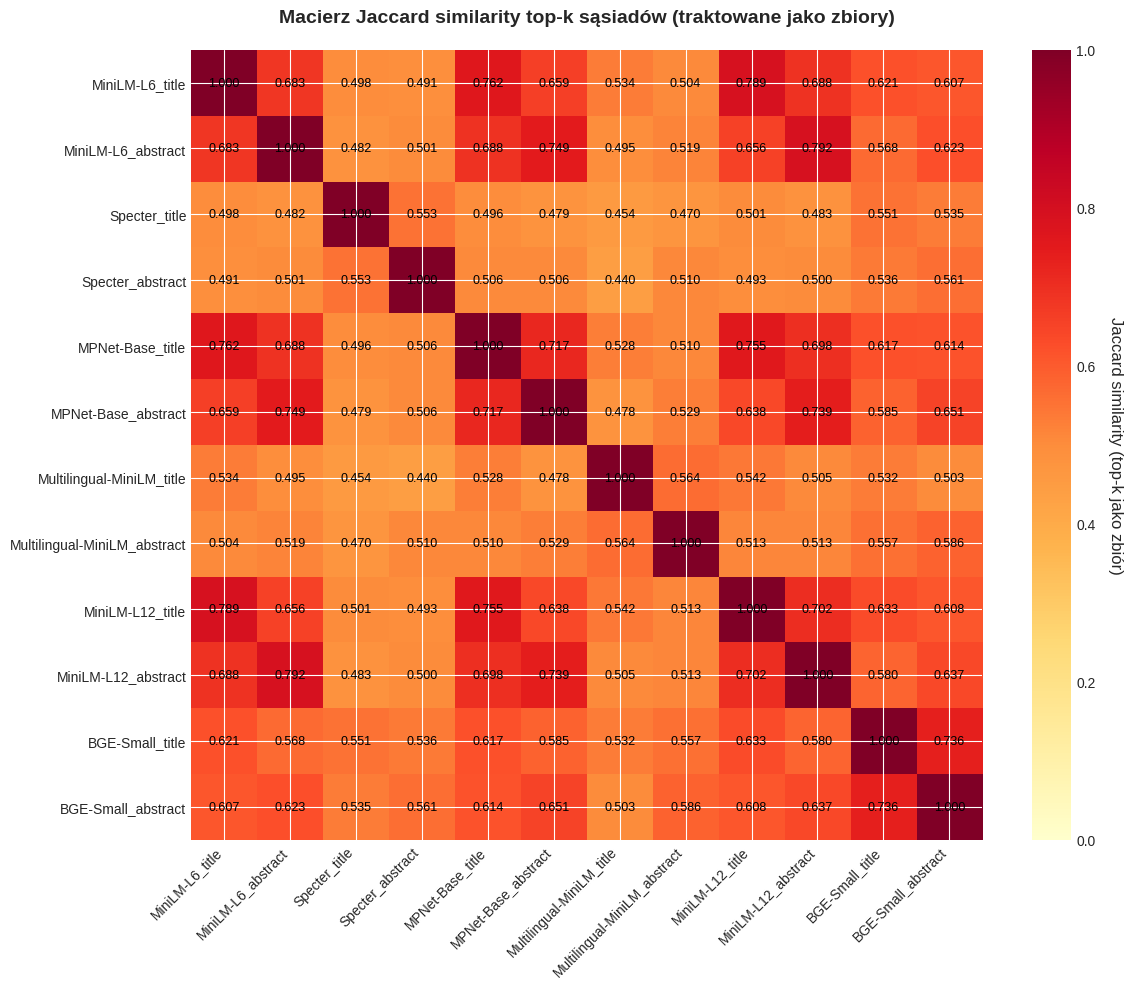

In [29]:
# Macierz nakładania (heatmap) - używamy Jaccard similarity
configs = list(all_neighbors.keys())
n_configs = len(configs)

jaccard_matrix = np.zeros((n_configs, n_configs))

for i, config1 in enumerate(configs):
    for j, config2 in enumerate(configs):
        if i == j:
            jaccard_matrix[i, j] = 1.0  # Perfect overlap with self
        elif i < j:
            pair_key = f"{config1} vs {config2}"
            jaccard_matrix[i, j] = comparison_results[pair_key]['mean_jaccard']
            jaccard_matrix[j, i] = jaccard_matrix[i, j]  # Symmetric

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(jaccard_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

# Dodaj colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Jaccard similarity (top-k jako zbiór)', rotation=270, labelpad=20, fontsize=12)

# Etykiety osi
ax.set_xticks(np.arange(n_configs))
ax.set_yticks(np.arange(n_configs))
ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(configs, fontsize=10)

# Dodaj wartości w komórkach
for i in range(n_configs):
    for j in range(n_configs):
        text = ax.text(j, i, f"{jaccard_matrix[i, j]:.3f}",
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Macierz Jaccard similarity top-k sąsiadów (traktowane jako zbiory)',
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

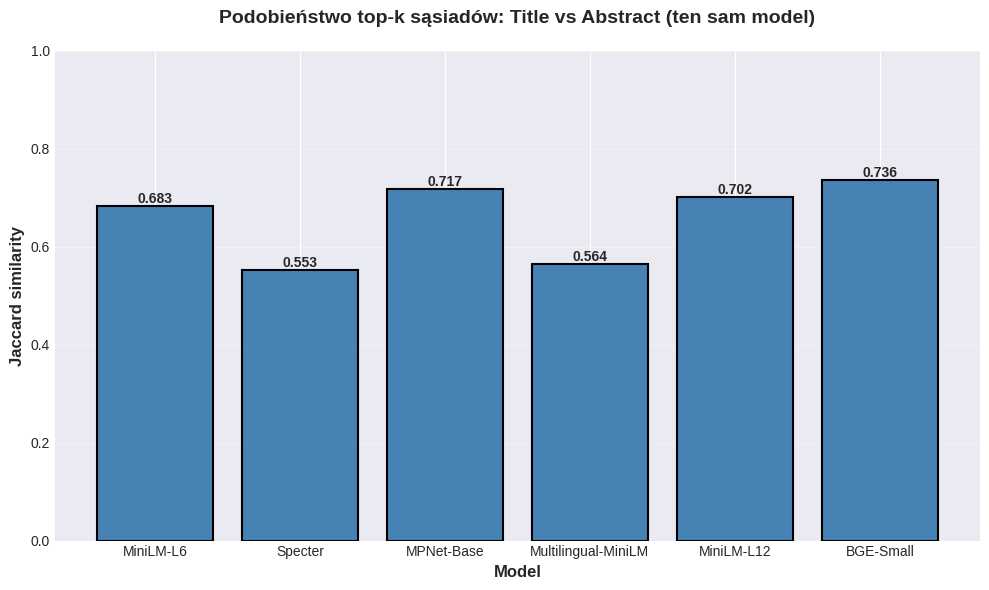

In [30]:
# Wykres słupkowy: porównanie tego samego modelu dla title vs abstract
same_model_comparisons = []

for model_name in MODELS.keys():
    config1 = f"{model_name}_title"
    config2 = f"{model_name}_abstract"
    
    if config1 in configs and config2 in configs:
        pair_key = f"{config1} vs {config2}"
        if pair_key in comparison_results:
            same_model_comparisons.append({
                'Model': model_name,
                'Jaccard': comparison_results[pair_key]['mean_jaccard'],
                'Overlap': comparison_results[pair_key]['mean_overlap']
            })

if same_model_comparisons:
    same_model_df = pd.DataFrame(same_model_comparisons)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Użyjemy Jaccard similarity dla wizualizacji
    bars = ax.bar(same_model_df['Model'], same_model_df['Jaccard'],
                  color='steelblue', edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Jaccard similarity', fontsize=12, fontweight='bold')
    ax.set_title('Podobieństwo top-k sąsiadów: Title vs Abstract (ten sam model)',
                fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Dodaj wartości na słupkach
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Brak danych do porównania title vs abstract")

## 8. Case Study: Analiza konkretnego naukowca

In [31]:
# Wybierz naukowca do analizy (zmień ORCID lub nazwisko)
SEARCH_NAME = "kubis"  # Możesz zmienić na dowolne nazwisko

# Znajdź ORCID naukowca
matching_scientists = df_scientists[
    df_scientists['full_name'].str.contains(SEARCH_NAME, case=False, na=False)
]

if len(matching_scientists) == 0:
    print(f"❌ Nie znaleziono naukowca: '{SEARCH_NAME}'")
    print(f"\n💡 Dostępni naukowcy (pierwsze 20):")
    for name in df_scientists['full_name'].head(20):
        print(f"   - {name}")
else:
    print(f"✅ Znaleziono {len(matching_scientists)} naukowca/ów:\n")
    
    for _, scientist in matching_scientists.iterrows():
        orcid = scientist['clean_orcid']
        name = scientist['full_name']
        
        print(f"{'='*80}")
        print(f"👤 NAUKOWIEC: {name}")
        print(f"   ORCID: {orcid}")
        print(f"{'='*80}")
        
        # Sprawdź czy naukowiec jest w wynikach
        sample_config = list(all_neighbors.keys())[0]
        if orcid not in all_neighbors[sample_config]:
            print(f"⚠️  Brak tego naukowca w wynikach (za mało prac?)")
            continue
        
        # Pokaż top-5 sąsiadów dla każdej konfiguracji
        print(f"\n📊 TOP-5 NAJBLIŻSZYCH SĄSIADÓW DLA RÓŻNYCH KONFIGURACJI:\n")
        
        for config_name in all_neighbors.keys():
            neighbors = all_neighbors[config_name][orcid][:5]
            
            print(f"\n  {config_name}:")
            print(f"  {'-'*70}")
            
            for rank, (neighbor_orcid, similarity) in enumerate(neighbors, 1):
                neighbor_name = orcid_to_name.get(neighbor_orcid, neighbor_orcid)
                print(f"    {rank}. {neighbor_name}")
                print(f"       Podobieństwo: {similarity:.4f} | ORCID: {neighbor_orcid}")
        
        print(f"\n{'='*80}\n")

✅ Znaleziono 1 naukowca/ów:

👤 NAUKOWIEC: dr Marek Kubis
   ORCID: 0000-0002-2016-2598

📊 TOP-5 NAJBLIŻSZYCH SĄSIADÓW DLA RÓŻNYCH KONFIGURACJI:


  MiniLM-L6_title:
  ----------------------------------------------------------------------
    1. dr Paweł Marek Skórzewski
       Podobieństwo: 0.8869 | ORCID: 0000-0002-5056-2808
    2. prof. UAM dr hab. Filip Graliński
       Podobieństwo: 0.8524 | ORCID: 0000-0001-8066-4533
    3. prof. UAM dr hab. Krzysztof Jassem
       Podobieństwo: 0.8421 | ORCID: 0000-0001-7122-9206
    4. prof. dr hab. Zygmunt Vetulani
       Podobieństwo: 0.8255 | ORCID: 0000-0003-4833-8601
    5. dr inż. Artur Adam Nowakowski
       Podobieństwo: 0.7495 | ORCID: 0000-0003-4473-0008

  MiniLM-L6_abstract:
  ----------------------------------------------------------------------
    1. dr Paweł Marek Skórzewski
       Podobieństwo: 0.8950 | ORCID: 0000-0002-5056-2808
    2. prof. UAM dr hab. Filip Graliński
       Podobieństwo: 0.8467 | ORCID: 0000-0001-8066-4533
  

## 9. Analiza: Naukowiec z najbardziej różnymi wynikami

Znajdźmy naukowca, dla którego różne modele/typy dają najbardziej różne rekomendacje sąsiadów.

In [32]:
print("="*80)
print("ANALIZA: NAUKOWIEC Z NAJBARDZIEJ RÓŻNYMI WYNIKAMI MIĘDZY MODELAMI")
print("="*80)
print()

# Lista wszystkich konfiguracji
configs = list(all_neighbors.keys())

if len(configs) < 2:
    print("⚠️  Potrzeba przynajmniej 2 konfiguracji do porównania")
else:
    # Znajdź wspólnych naukowców we wszystkich konfiguracjach
    common_orcids = set(all_neighbors[configs[0]].keys())
    for config in configs[1:]:
        common_orcids &= set(all_neighbors[config].keys())
    
    print(f"📊 Wspólnych naukowców we wszystkich konfiguracjach: {len(common_orcids)}")
    print()
    
    if len(common_orcids) == 0:
        print("⚠️  Brak wspólnych naukowców we wszystkich konfiguracjach")
    else:
        # Dla każdego naukowca oblicz średnie podobieństwo Jaccard między wszystkimi parami konfiguracji
        scientist_similarities = {}
        
        for orcid in common_orcids:
            similarities = []
            
            # Porównaj wszystkie pary konfiguracji dla tego naukowca
            for i, config1 in enumerate(configs):
                for j, config2 in enumerate(configs):
                    if i >= j:  # Tylko górny trójkąt macierzy
                        continue
                    
                    # Pobierz zbiory sąsiadów
                    neighbors_set1 = set([n[0] for n in all_neighbors[config1][orcid]])
                    neighbors_set2 = set([n[0] for n in all_neighbors[config2][orcid]])
                    
                    # Jaccard similarity
                    intersection = len(neighbors_set1 & neighbors_set2)
                    union = len(neighbors_set1 | neighbors_set2)
                    jaccard = intersection / union if union > 0 else 0
                    
                    similarities.append(jaccard)
            
            # Średnie podobieństwo dla tego naukowca
            scientist_similarities[orcid] = np.mean(similarities)
        
        # Znajdź naukowca z najniższym średnim podobieństwem (najbardziej różne wyniki)
        most_different_orcid = min(scientist_similarities, key=scientist_similarities.get)
        min_similarity = scientist_similarities[most_different_orcid]
        
        # Znajdź też naukowca z najwyższym podobieństwem (dla kontrastu)
        most_similar_orcid = max(scientist_similarities, key=scientist_similarities.get)
        max_similarity = scientist_similarities[most_similar_orcid]
        
        print(f"🔍 WYNIKI ANALIZY:")
        print()
        print(f"📉 Naukowiec z NAJNIŻSZYM średnim podobieństwem (najbardziej różne wyniki):")
        print(f"   ORCID: {most_different_orcid}")
        print(f"   Nazwisko: {orcid_to_name.get(most_different_orcid, 'Nieznany')}")
        print(f"   Średnie Jaccard similarity: {min_similarity:.4f}")
        print(f"   → Modele są MAŁO zgodne co do sąsiadów tego naukowca")
        print()
        print(f"📈 Dla kontrastu - Naukowiec z NAJWYŻSZYM średnim podobieństwem:")
        print(f"   ORCID: {most_similar_orcid}")
        print(f"   Nazwisko: {orcid_to_name.get(most_similar_orcid, 'Nieznany')}")
        print(f"   Średnie Jaccard similarity: {max_similarity:.4f}")
        print(f"   → Modele są BARDZO zgodne co do sąsiadów tego naukowca")
        print()
        print("="*80)
        print()
        
        # Pokaż szczegółową analizę naukowca z najbardziej różnymi wynikami
        selected_orcid = most_different_orcid
        selected_name = orcid_to_name.get(selected_orcid, 'Nieznany')
        
        print(f"📋 SZCZEGÓŁOWA ANALIZA: {selected_name}")
        print(f"   ORCID: {selected_orcid}")
        print("="*80)
        print()
        print("🔎 TOP-5 SĄSIADÓW DLA KAŻDEJ KONFIGURACJI:")
        print()
        
        # Grupuj konfiguracje po modelach dla lepszej czytelności
        configs_by_model = {}
        for config in configs:
            if '_' in config:
                model_name, emb_type = config.rsplit('_', 1)
                if model_name not in configs_by_model:
                    configs_by_model[model_name] = []
                configs_by_model[model_name].append((config, emb_type))
        
        # Wyświetl sąsiadów dla każdego modelu
        for model_name in sorted(configs_by_model.keys()):
            print(f"\n{'='*80}")
            print(f"🤖 MODEL: {model_name}")
            print(f"{'='*80}")
            
            for config, emb_type in sorted(configs_by_model[model_name], key=lambda x: x[1]):
                neighbors = all_neighbors[config][selected_orcid][:5]
                
                print(f"\n  📄 Typ: {emb_type.upper()}")
                print(f"  {'-'*70}")
                
                for rank, (neighbor_orcid, similarity) in enumerate(neighbors, 1):
                    neighbor_name = orcid_to_name.get(neighbor_orcid, neighbor_orcid)
                    print(f"    {rank}. {neighbor_name}")
                    print(f"       Podobieństwo: {similarity:.4f} | ORCID: {neighbor_orcid}")
        
        print(f"\n{'='*80}")
        print()
        
        # Analiza nakładania się sąsiadów między konfiguracjami
        print(f"📊 MACIERZ PODOBIEŃSTWA SĄSIADÓW (Jaccard similarity):")
        print(f"    Dla naukowca: {selected_name}")
        print()
        
        # Utwórz małą macierz podobieństwa dla tego naukowca
        n_configs = len(configs)
        jaccard_matrix_scientist = np.zeros((n_configs, n_configs))
        
        for i, config1 in enumerate(configs):
            for j, config2 in enumerate(configs):
                if i == j:
                    jaccard_matrix_scientist[i, j] = 1.0
                else:
                    neighbors_set1 = set([n[0] for n in all_neighbors[config1][selected_orcid]])
                    neighbors_set2 = set([n[0] for n in all_neighbors[config2][selected_orcid]])
                    
                    intersection = len(neighbors_set1 & neighbors_set2)
                    union = len(neighbors_set1 | neighbors_set2)
                    jaccard = intersection / union if union > 0 else 0
                    
                    jaccard_matrix_scientist[i, j] = jaccard
        
        # Wyświetl macierz jako tekst (małe wersje konfiguracji)
        config_short_names = [c.replace('Multilingual-MiniLM', 'Multi-ML') for c in configs]
        
        # Header
        print(f"{'':20}", end='')
        for config_short in config_short_names[:min(8, len(configs))]:  # Max 8 kolumn
            print(f"{config_short[:18]:>20}", end='')
        print()
        print("-" * (20 + 20 * min(8, len(configs))))
        
        # Wiersze
        for i, config1 in enumerate(configs[:min(8, len(configs))]):
            config_short = config_short_names[i]
            print(f"{config_short[:18]:20}", end='')
            
            for j in range(min(8, len(configs))):
                value = jaccard_matrix_scientist[i, j]
                color = '🟢' if value > 0.7 else '🟡' if value > 0.4 else '🔴'
                print(f"{color} {value:.3f}           ", end='')
            print()
        
        print()
        print("Legenda: 🟢 Wysokie podobieństwo (>0.7)  🟡 Średnie (0.4-0.7)  🔴 Niskie (<0.4)")
        print()
        
        # Podsumowanie
        print(f"💡 INTERPRETACJA:")
        print(f"   - Naukowiec '{selected_name}' ma średnie podobieństwo Jaccard: {min_similarity:.4f}")
        print(f"   - Oznacza to, że różne modele/typy proponują RÓŻNYCH sąsiadów")
        print(f"   - To może wskazywać na:")
        print(f"     • Wielowymiarowy profil badawczy (różne obszary badań)")
        print(f"     • Prace z pogranicza dziedzin")
        print(f"     • Silną zależność od kontekstu (title vs abstract vs n_grams)")
        print()

print("="*80)
print("ANALIZA ZAKOŃCZONA")
print("="*80)

ANALIZA: NAUKOWIEC Z NAJBARDZIEJ RÓŻNYMI WYNIKAMI MIĘDZY MODELAMI

📊 Wspólnych naukowców we wszystkich konfiguracjach: 107

🔍 WYNIKI ANALIZY:

📉 Naukowiec z NAJNIŻSZYM średnim podobieństwem (najbardziej różne wyniki):
   ORCID: 0000-0002-8578-8997
   Nazwisko: dr Andrzej Kokosza
   Średnie Jaccard similarity: 0.2836
   → Modele są MAŁO zgodne co do sąsiadów tego naukowca

📈 Dla kontrastu - Naukowiec z NAJWYŻSZYM średnim podobieństwem:
   ORCID: 0000-0002-2016-2598
   Nazwisko: dr Marek Kubis
   Średnie Jaccard similarity: 0.8600
   → Modele są BARDZO zgodne co do sąsiadów tego naukowca


📋 SZCZEGÓŁOWA ANALIZA: dr Andrzej Kokosza
   ORCID: 0000-0002-8578-8997

🔎 TOP-5 SĄSIADÓW DLA KAŻDEJ KONFIGURACJI:


🤖 MODEL: BGE-Small

  📄 Typ: ABSTRACT
  ----------------------------------------------------------------------
    1. dr Wojciech Piotr Pałubicki
       Podobieństwo: 0.9508 | ORCID: 0000-0002-2374-346X
    2. dr Abhishek Goswami
       Podobieństwo: 0.8132 | ORCID: 0000-0001-6868-8815
 

In [33]:
# Ranking naukowców - TOP 10 z najbardziej różnymi wynikami
if len(configs) >= 2 and len(common_orcids) > 0:
    print("="*80)
    print("📊 RANKING: TOP 10 NAUKOWCÓW Z NAJBARDZIEJ RÓŻNYMI WYNIKAMI")
    print("="*80)
    print()
    
    # Sortuj naukowców według podobieństwa (rosnąco)
    sorted_scientists = sorted(scientist_similarities.items(), key=lambda x: x[1])
    
    # Pokaż top 10 z najniższym podobieństwem
    top_10_different = sorted_scientists[:min(10, len(sorted_scientists))]
    
    print("🔴 Najbardziej RÓŻNE wyniki między modelami:")
    print()
    print(f"{'Rank':<6} {'Nazwisko':<40} {'ORCID':<20} {'Śr. Jaccard':<15}")
    print("-" * 81)
    
    for rank, (orcid, similarity) in enumerate(top_10_different, 1):
        name = orcid_to_name.get(orcid, 'Nieznany')
        print(f"{rank:<6} {name[:38]:<40} {orcid:<20} {similarity:.4f}")
    
    print()
    print("💡 Ci naukowcy mają najbardziej RÓŻNE profile w różnych modelach/typach")
    print()
    
    # Dla kontrastu - top 10 z najwyższym podobieństwem
    top_10_similar = sorted_scientists[-min(10, len(sorted_scientists)):][::-1]
    
    print("="*80)
    print()
    print("🟢 Najbardziej PODOBNE wyniki między modelami:")
    print()
    print(f"{'Rank':<6} {'Nazwisko':<40} {'ORCID':<20} {'Śr. Jaccard':<15}")
    print("-" * 81)
    
    for rank, (orcid, similarity) in enumerate(top_10_similar, 1):
        name = orcid_to_name.get(orcid, 'Nieznany')
        print(f"{rank:<6} {name[:38]:<40} {orcid:<20} {similarity:.4f}")
    
    print()
    print("💡 Ci naukowcy mają najbardziej SPÓJNE profile we wszystkich modelach/typach")
    print()
    
    # Histogram rozkładu podobieństw
    print("="*80)
    print("📈 ROZKŁAD PODOBIEŃSTW:")
    print()
    
    all_similarities = list(scientist_similarities.values())
    
    bins = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    hist, _ = np.histogram(all_similarities, bins=bins)
    
    print(f"Przedział Jaccard | Liczba naukowców | Procent")
    print("-" * 60)
    
    for i in range(len(bins)-1):
        count = hist[i]
        percent = (count / len(all_similarities)) * 100
        bar = '█' * int(percent / 2)
        print(f"  {bins[i]:.1f} - {bins[i+1]:.1f}     | {count:>5}            | {percent:>5.1f}% {bar}")
    
    print()
    print(f"Średnie podobieństwo: {np.mean(all_similarities):.4f}")
    print(f"Mediana podobieństwa: {np.median(all_similarities):.4f}")
    print(f"Odchylenie std: {np.std(all_similarities):.4f}")
    print()
    print("="*80)

📊 RANKING: TOP 10 NAUKOWCÓW Z NAJBARDZIEJ RÓŻNYMI WYNIKAMI

🔴 Najbardziej RÓŻNE wyniki między modelami:

Rank   Nazwisko                                 ORCID                Śr. Jaccard    
---------------------------------------------------------------------------------
1      dr Andrzej Kokosza                       0000-0002-8578-8997  0.2836
2      mgr inż. Piotr Adam Jabłoński            0000-0001-9360-3502  0.2923
3      dr Janusz Przewocki                      0000-0003-4265-7353  0.3335
4      prof. UAM dr hab. Maciej Radziejewski    0000-0001-8568-7494  0.3625
5      prof. dr hab. Roman Murawski             0000-0002-2392-4869  0.3795
6      prof. dr hab. Wojciech Buszkowski        0000-0002-2950-0864  0.3839
7      dr Paweł Duch                            0000-0002-2445-2189  0.3880
8      dr Sohail Farhangi                       0000-0001-8183-6157  0.3894
9      dr Wojciech Piotr Pałubicki              0000-0002-2374-346X  0.3930
10     prof. dr hab. Jerzy Kaczorowski      

## Wymiary embeddingów dla różnych modeli

Sprawdźmy ile wymiarów ma każdy model embeddingowy.

In [34]:
print("="*80)
print("📏 WYMIARY EMBEDDINGÓW DLA RÓŻNYCH MODELI")
print("="*80)
print()

# Zbierz informacje o wymiarach z wygenerowanych profili
model_dimensions = {}

for config_name, profiles in all_profiles.items():
    if profiles:  # Jeśli są jakieś profile
        # Pobierz pierwszy profil i sprawdź jego wymiar
        first_orcid = list(profiles.keys())[0]
        embedding = profiles[first_orcid]
        dimension = len(embedding)
        
        # Wyodrębnij nazwę modelu i typ
        if '_' in config_name:
            model_name, emb_type = config_name.rsplit('_', 1)
            
            if model_name not in model_dimensions:
                model_dimensions[model_name] = {
                    'dimension': dimension,
                    'types': []
                }
            
            model_dimensions[model_name]['types'].append(emb_type)

# Wyświetl wyniki
if model_dimensions:
    print(f"{'Model':<30} {'Wymiar':<15} {'Dostępne typy':<40}")
    print("-" * 85)
    
    # Sortuj modele alfabetycznie
    for model_name in sorted(model_dimensions.keys()):
        info = model_dimensions[model_name]
        dimension = info['dimension']
        types = ', '.join(sorted(info['types']))
        
        print(f"{model_name:<30} {dimension:<15} {types:<40}")
    
    print()
    print("="*85)
    print()
    
    # Porównanie wymiarów
    dimensions_list = [info['dimension'] for info in model_dimensions.values()]
    unique_dimensions = sorted(set(dimensions_list))
    
    print(f"📊 STATYSTYKI WYMIARÓW:")
    print()
    print(f"   Unikalne wymiary: {unique_dimensions}")
    print(f"   Najmniejszy wymiar: {min(dimensions_list)}")
    print(f"   Największy wymiar: {max(dimensions_list)}")
    print(f"   Średni wymiar: {np.mean(dimensions_list):.1f}")
    print()
    
    # Grupuj modele według wymiarów
    print(f"📋 MODELE POGRUPOWANE WEDŁUG WYMIARÓW:")
    print()
    
    dims_to_models = {}
    for model_name, info in model_dimensions.items():
        dim = info['dimension']
        if dim not in dims_to_models:
            dims_to_models[dim] = []
        dims_to_models[dim].append(model_name)
    
    for dim in sorted(dims_to_models.keys()):
        models = dims_to_models[dim]
        print(f"   {dim} wymiarów:")
        for model in sorted(models):
            print(f"      - {model}")
        print()
    
    print("="*85)
    print()
    
    # Mapowanie nazw skróconych na pełne
    model_full_names = {v: k for k, v in MODELS.items()}
    
    print(f"💡 INTERPRETACJA:")
    print()
    print(f"   Wyższa liczba wymiarów ≠ lepszy model!")
    print(f"   - Więcej wymiarów = więcej parametrów = potencjalnie bardziej szczegółowa reprezentacja")
    print(f"   - Mniej wymiarów = szybsze obliczenia, mniej pamięci, czasem lepsze uogólnienie")
    print()
    print(f"   Przykłady:")
    for model_short, model_full in model_full_names.items():
        if model_short in model_dimensions:
            dim = model_dimensions[model_short]['dimension']
            if dim <= 384:
                note = "(szybki, kompaktowy)"
            elif dim <= 768:
                note = "(balans szybkości i jakości)"
            else:
                note = "(wysoka jakość, wolniejszy)"
            
            print(f"   - {model_short}: {dim} wymiarów {note}")
    
    print()
    print("="*85)
    
else:
    print("⚠️  Brak wygenerowanych profili do analizy")
    print("   Najpierw uruchom sekcję eksperymentu (sekcja 5)")
    print()
    print("="*80)

📏 WYMIARY EMBEDDINGÓW DLA RÓŻNYCH MODELI

Model                          Wymiar          Dostępne typy                           
-------------------------------------------------------------------------------------
BGE-Small                      384             abstract, title                         
MPNet-Base                     768             abstract, title                         
MiniLM-L12                     384             abstract, title                         
MiniLM-L6                      384             abstract, title                         
Multilingual-MiniLM            384             abstract, title                         
Specter                        768             abstract, title                         


📊 STATYSTYKI WYMIARÓW:

   Unikalne wymiary: [384, 768]
   Najmniejszy wymiar: 384
   Największy wymiar: 768
   Średni wymiar: 512.0

📋 MODELE POGRUPOWANE WEDŁUG WYMIARÓW:

   384 wymiarów:
      - BGE-Small
      - MiniLM-L12
      - MiniLM-L6
      - M

## 11. Podsumowanie

### Interpretacja wyników:

**Jaccard similarity** mierzy podobieństwo zbiorów top-k sąsiadów:
- **Wysokie podobieństwo** (>0.7): Modele/konfiguracje tworzą bardzo podobne profile i identyfikują tych samych sąsiadów
- **Średnie podobieństwo** (0.4-0.7): Modele częściowo się zgadzają, ale mają różne "punkty widzenia"
- **Niskie podobieństwo** (<0.4): Modele tworzą bardzo różne profile naukowców

**WAŻNE**: Top-k sąsiadów traktowane są jako **zbiory** - liczy się tylko czy ci sami naukowcy są w grupie, nie ich kolejność.

### Pytania badawcze:

1. Czy title vs abstract dają podobne wyniki dla tego samego modelu?
2. Które modele są najbardziej zgodne ze sobą?
3. Czy wielojęzyczny model daje różne wyniki od anglojęzycznych?
4. Czy specjalistyczny model (Specter) daje lepsze/inne wyniki?
5. **NOWE**: Czy embeddingi N-gramów dają inne wyniki niż zwykłe embeddingi title/abstract?
6. **NOWE**: Którzy naukowcy mają najbardziej różne profile w różnych modelach?

### Typy embeddingów:

Notebook obsługuje trzy typy embeddingów:

#### 1. **Title** - Embedding tytułu pracy
- Szybki do wygenerowania
- Zawiera tylko najważniejsze słowa kluczowe
- Dobry dla ogólnego porównania tematyki

#### 2. **Abstract** - Embedding całego abstractu
- Wolniejszy do wygenerowania
- Zawiera pełny kontekst badania
- Lepszy dla szczegółowej analizy tematyki

#### 3. **N-grams** - Embedding centrum N-gramów zdań z abstractu (NOWOŚĆ!)
- Dzieli abstract na zdania
- Tworzy N-gramy różnych długości (1 zdanie, 2 zdania, ..., cały abstract)
- Embeduje każdy N-gram osobno
- Oblicza centroid (średnią) wszystkich embeddingów
- **Zalety**: Uchwycuje różne konteksty (lokalne i globalne), bardziej odporny na szum
- **Wymaga**: Wcześniejszego wygenerowania przez `generate_work_embeddings.ipynb`
- **UWAGA**: Tylko w trybie MODE='LOAD'

### Tryby pracy:

#### MODE = 'LOAD' (zalecany, obsługuje wszystkie typy)
```python
MODE = 'LOAD'  # Wczytaj embeddingi prac wygenerowane przez generate_work_embeddings.ipynb
EMBEDDING_TYPES = ['title', 'abstract', 'n_grams']  # Wszystkie typy
```
- **Szybszy** - nie trzeba generować embeddingów od nowa
- **Wymaga**: wcześniejszego uruchomienia `generate_work_embeddings.ipynb`
- Wczytuje embeddingi z:
  - `embeddings/titles/{model}/`
  - `embeddings/abstracts/{model}/`
  - `embeddings/n_grams/{model}/` ← dla N-gramów
- Oblicza centroids (profile naukowców) z wczytanych embeddingów
- **Obsługuje wszystkie typy**: title, abstract, n_grams

#### MODE = 'GENERATE' (tylko title i abstract)
```python
MODE = 'GENERATE'  # Generuj embeddingi od nowa (jak dotychczas)
EMBEDDING_TYPES = ['title', 'abstract']  # N-grams NIE jest wspierane
```
- **Wolniejszy** - generuje wszystkie embeddingi podczas działania
- **Nie wymaga** wcześniejszych kroków
- Embeduje wszystkie prace i oblicza centroids w locie
- **OGRANICZENIE**: Nie obsługuje typu 'n_grams'

### Zapis/wczyt profili (centroidów):

**Profle** (centroids naukowców) są zapisywane osobno w katalogu `{EMBEDDINGS_DIR}`:
- `embeddings_{model_name}_{emb_type}.pkl`

Przykłady:
- `embeddings_MiniLM-L6_title.pkl`
- `embeddings_Specter_abstract.pkl`
- `embeddings_MiniLM-L6_n_grams.pkl` ← dla N-gramów

Zmienne kontrolne dla profili:
- `LOAD_PROFILES = True/False` - wczytaj profile z plików czy oblicz
- `SAVE_PROFILES = True/False` - zapisz profile po obliczeniu

### Typowy workflow:

#### Wariant A: Z N-gramami (zalecany)

1. **Krok 1**: Wygeneruj embeddingi prac (jednorazowo)
   ```python
   # W generate_work_embeddings.ipynb
   MODELS = ['all-MiniLM-L6-v2', 'allenai/specter']
   EMB_TYPES = ['title', 'abstract', 'n_grams']
   # Uruchom -> wygeneruje wszystkie embeddingi
   ```

2. **Krok 2**: Porównaj modele (wielokrotnie, szybko)
   ```python
   # W scientist_profile_comparison.ipynb
   MODE = 'LOAD'
   EMBEDDING_TYPES = ['title', 'abstract', 'n_grams']
   LOAD_PROFILES = False
   SAVE_PROFILES = True
   # Uruchom -> szybko wczyta embeddingi i obliczy profile
   ```

3. **Krok 3**: Kolejne analizy (bardzo szybko)
   ```python
   MODE = 'LOAD'
   LOAD_PROFILES = True  # Wczyta gotowe profile
   # Uruchom -> natychmiastowo, tylko analiza sąsiadów
   ```

#### Wariant B: Bez N-gramów (prostszy)

1. **Krok jedyny**: Generuj i porównuj
   ```python
   # W scientist_profile_comparison.ipynb
   MODE = 'GENERATE'
   EMBEDDING_TYPES = ['title', 'abstract']
   # Uruchom -> wygeneruje i porówna w jednym kroku
   ```

### Przykład konfiguracji z N-gramami:

```python
# Konfiguracja
EMBEDDING_TYPES = ['title', 'abstract', 'n_grams']
MODE = 'LOAD'

# To wygeneruje dla każdego modelu 3 konfiguracje:
# - MiniLM-L6_title
# - MiniLM-L6_abstract  
# - MiniLM-L6_n_grams  ← NOWY TYP!
# 
# I porówna wszystkie pary między sobą
```

### Porównanie typów embeddingów:

| Typ | Czas generacji | Jakość kontekstu | Odporność na szum | Tryb GENERATE | Tryb LOAD |
|-----|---------------|------------------|-------------------|---------------|-----------|
| **title** | Bardzo szybki | Niska (tylko tytuł) | Niska | ✅ | ✅ |
| **abstract** | Szybki | Średnia | Średnia | ✅ | ✅ |
| **n_grams** | Wolny (10-50x) | Wysoka (multi-scale) | Wysoka | ❌ | ✅ |

### Struktura katalogów:

```
embeddings/
├── titles/
│   ├── all-MiniLM-L6-v2/
│   │   └── W123_title.pkl
│   └── allenai-specter/
│       └── W123_title.pkl
├── abstracts/
│   ├── all-MiniLM-L6-v2/
│   │   └── W123_abstract.pkl
│   └── allenai-specter/
│       └── W123_abstract.pkl
├── n_grams/                        ← NOWY KATALOG
│   ├── all-MiniLM-L6-v2/
│   │   └── W123_n_grams.pkl
│   └── allenai-specter/
│       └── W123_n_grams.pkl
└── embeddings_MiniLM-L6_title.pkl      # Profile naukowców
    embeddings_MiniLM-L6_abstract.pkl
    embeddings_MiniLM-L6_n_grams.pkl    ← NOWY PROFIL
    ...